### [Step 1] 심리적 성공 지표(Success Signals) 간 상관관계 및 VIF 검증
`velocity`, `sentiment`, `value_score`, `stability` 등 핵심 지표 간의 선형 상관관계를 히트맵으로 시각화합니다. 또한 다중공선성(VIF) 검증을 통해 지표 간 독립성을 확인하여 분석의 통계적 타당성을 확보합니다.

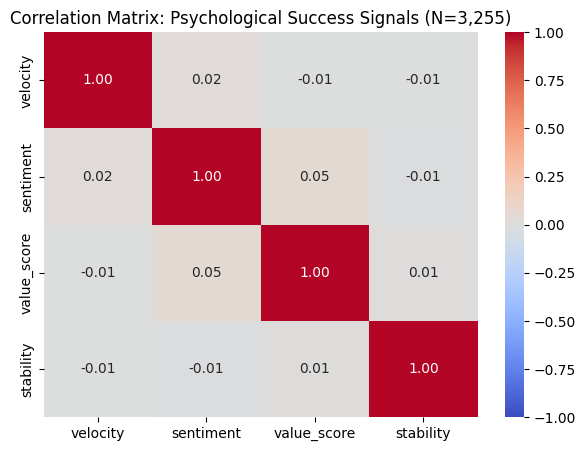

========== 다중공선성 검증 결과 (VIF) ==========
  Signal_Indicator  VIF_Score
1        sentiment   1.003191
2      value_score   1.002697
0         velocity   1.000726
3        stability   1.000423


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. 데이터 로드
base_path = '../../../../data/preprocessed/'
df = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
hist_df = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

# -------------------------------------------------------------------
# 🎯 [지표 정의] 본 분석용 4대 시그널 생성 (심리적 가성비 포함)
# -------------------------------------------------------------------

# [1] Stability (민심 안정도): 전체 기간 일별 긍정률의 표준편차
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / 
                            (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_df = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

# 데이터 통합
df = pd.merge(df, stability_df, on='appid', how='left')

# [2] Velocity (리뷰의 양): 전체 리뷰 총량
df['velocity'] = df['total_reviews']

# [3] Sentiment (민심): 전체 긍정률
df['sentiment'] = df['positive_rate']

# [4] Value Score (심리적 가성비): 소유자 대비 추천 수의 비중
# 의미: 구매자 중 추천을 남길 정도로 심리적 가성비가 충족된 유저의 비율
df['recommendations_total'] = df['recommendations_total'].fillna(0)
df['value_score'] = df['recommendations_total'] / (df['owners_lower'] + 1)

# -------------------------------------------------------------------
# 📊 지표 타당성 및 다중공선성(VIF) 검증
# -------------------------------------------------------------------

signal_columns = ['velocity', 'sentiment', 'value_score', 'stability']
analysis_df = df[signal_columns].replace([np.inf, -np.inf], np.nan).fillna(0)

# 1. 상관관계 히트맵 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(analysis_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Psychological Success Signals (N=3,255)')
plt.show()

# 2. 다중공선성(VIF) 검증
analysis_df_vif = analysis_df.copy()
analysis_df_vif['const'] = 1 
vif_data = pd.DataFrame()
vif_data["Signal_Indicator"] = analysis_df_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(analysis_df_vif.values, i) for i in range(analysis_df_vif.shape[1])]

print("========== 다중공선성 검증 결과 (VIF) ==========")
print(vif_data[vif_data['Signal_Indicator'] != 'const'].sort_values(by="VIF_Score", ascending=False))